## Risk-Stratified Survival Analysis -- Above Crossover Survival Estimate

**This notebook analyzes overall survival among patients with metastatic clear cell RCC who received first-line combination immunotherapy or single-agent antiangenic therpay with a predicted 6 month survival probability above the crossover survival estimate.**

In [1]:
import numpy as np
import pandas as pd

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt
from lifelines.plotting import add_at_risk_counts

## Import data

In [2]:
treatment_df = pd.read_csv('../outputs/ioio_tki_index.csv')

In [3]:
treatment_df.sample(3)

,PatientID,LineName,StartDate
176,F1D651A046779,ioio,2018-12-26
2293,FC15109F98433,tki,2013-07-03
2479,FF6E2E53B0270,tki,2013-05-10


In [4]:
treatment_df.shape

(4831, 3)

In [5]:
treatment_df['treatment'] = (treatment_df['LineName'] == 'ioio').astype(int)

In [6]:
dtype_map = pd.read_csv('../outputs/ioio_tki_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/ioio_tki_features.csv', dtype = dtype_map)

In [7]:
features_df.shape

(4366, 161)

In [8]:
surv_pred_df = pd.read_csv('../outputs/gb_6m_survival_predictions_calibrated.csv')

In [9]:
df = pd.merge(features_df, treatment_df, on = 'PatientID', how = 'left')

In [10]:
df.shape

(4366, 164)

In [11]:
df = pd.merge(df, surv_pred_df, on = 'PatientID', how = 'left')

In [12]:
df.shape

(4366, 165)

In [13]:
df = df.query('met_diagnosis_year <= 2020')

In [14]:
df.shape

(4193, 165)

In [15]:
with open('../outputs/crossover_survival_estimate.txt', 'r') as f:
    crossover_survival_estimate = float(f.read())

In [16]:
df = df.query('psurv_180_calibrated >= @crossover_survival_estimate')

In [17]:
df.shape

(3527, 165)

## Survival analysis with IPTW

In [18]:
df.treatment.value_counts()

treatment
0    2912
1     615
Name: count, dtype: int64

In [19]:
(
    df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.320742
1    0.601626
Name: event, dtype: float64

In [20]:
estimator = IPTWSurvivalEstimator()

In [21]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['GroupStage'],
              cont_var = ['days_diagnosis_to_met', 'age', 'ecog_index', 'weight_index', 'percent_change_weight', 'albumin', 'creatinine', 'calcium', 'neutrophil', 'platelet', 'hemoglobin', 'van_walraven_score'],
              binary_var = ['Nephrectomy_mod', 'ecog_index_na', 'SmokingStatus', 'commercial', 'medicaid', 'days_to_treatment_before_1y'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,
              use_missing_flags = False)

In [22]:
iptw_df = estimator.transform()

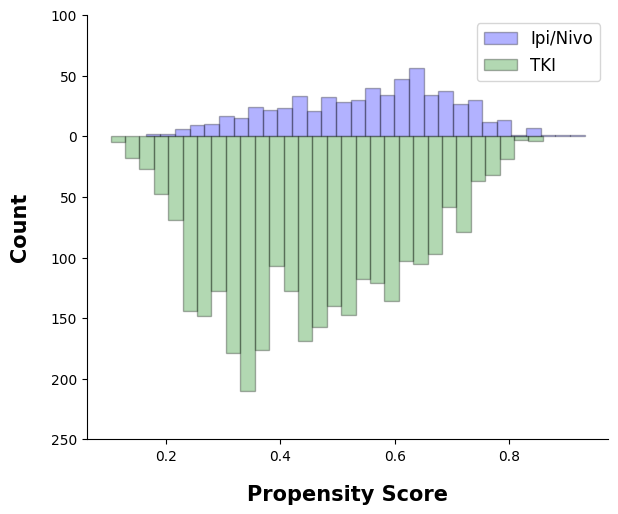

In [23]:
ps_fig = estimator.propensity_score_plot(bins = 30)

ax = ps_fig.axes[0]

ax.set_xlabel('Propensity Score', fontsize = 15)
ax.set_ylabel('Count', fontsize = 15)
ax.set_title('')
ps_fig.set_size_inches(6, 6)

handles, labels = ax.get_legend_handles_labels()
label_map = {'Treatment': 'Ipi/Nivo', 'Control': 'TKI'}
ax.legend(handles, [label_map.get(l, l) for l in labels], prop={'size': 12})

ps_fig

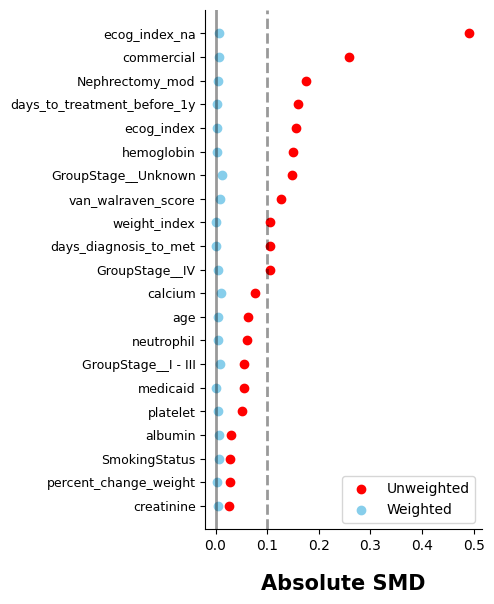

In [24]:
_, smd_fig = estimator.standardized_mean_differences(return_fig = True)

ax = smd_fig.axes[0]

# Resize figure
smd_fig.set_size_inches(4, 6)

# Axis/title font sizes
ax.set_xlabel('Absolute SMD', fontsize=15)
ax.set_title('')

# Reference line styles
for line in ax.lines:
    line.set_alpha(0.4)

ax.tick_params(axis='y', labelsize=9)
ax.legend(prop={'size': 10})
smd_fig

In [25]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42)

In [26]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [365, 730, 1095],
                                     rmst_time_points = [365, 730, 1095],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42,
                                     n_jobs = -1)

In [27]:
# Median results
print('Median survival results')
print(f'IO-TKI: {tuple(round(x / 30, 1) for x in results['treatment']['median'])} months')
print(f'IO-IO: {tuple(round(x / 30, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x / 30, 1) for x in results['difference']['median'])} months')

Median survival results
IO-TKI: (34.1, 27.7, 38.3) months
IO-IO: (28.9, 27.0, 31.2) months
Difference: (5.2, -1.2, 9.7) months


In [28]:
print('RMST results at 1 year')
print(f'IO-IO: {tuple(round(x, 1) for x in results['treatment']['rmst'][365])} days')
print(f'TKI: {tuple(round(x, 1) for x in results['control']['rmst'][365])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][365])} days')

print('')
print('RMST results at 2 years')
print(f'IO-IO: {tuple(round(x, 1) for x in results['treatment']['rmst'][730])} days')
print(f'TKI: {tuple(round(x, 1) for x in results['control']['rmst'][730])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][730])} days')

print('')
print('RMST results at 3 years')
print(f'IO-IO: {tuple(round(x, 1) for x in results['treatment']['rmst'][1095])} days')
print(f'TKI: {tuple(round(x, 1) for x in results['control']['rmst'][1095])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][1095])} days')

RMST results at 1 year
IO-IO: (318.1, 309.2, 325.7) days
TKI: (317.5, 313.6, 321.1) days
Difference: (0.6, -8.9, 9.1) days

RMST results at 2 years
IO-IO: (566.8, 545.2, 586.7) days
TKI: (551.0, 540.3, 560.8) days
Difference: (15.8, -7.6, 37.6) days

RMST results at 3 years
IO-IO: (760.3, 724.5, 794.6) days
TKI: (728.9, 712.4, 745.2) days
Difference: (31.4, -8.4, 69.5) days


In [29]:
print('Probability of survival at 1 year')
print(f'IO-IO: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][365])}')
print(f'TKI: {tuple(round(x, 3) for x in results['control']['survival_prob'][365])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][365])}')

print('')
print('Probability of survival at 2 years')
print(f'IO-IO: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][730])}')
print(f'TKI: {tuple(round(x, 3) for x in results['control']['survival_prob'][730])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][730])}')

print('')
print('Probability of survival at 3 years')
print(f'IO-IO: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][1095])}')
print(f'TKI: {tuple(round(x, 3) for x in results['control']['survival_prob'][1095])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][1095])}')

Probability of survival at 1 year
IO-IO: (0.769, 0.733, 0.803)
TKI: (0.734, 0.715, 0.752)
Difference: (0.034, -0.007, 0.07)

Probability of survival at 2 years
IO-IO: (0.591, 0.541, 0.635)
TKI: (0.556, 0.536, 0.576)
Difference: (0.035, -0.015, 0.083)

Probability of survival at 3 years
IO-IO: (0.464, 0.409, 0.525)
TKI: (0.433, 0.413, 0.456)
Difference: (0.03, -0.031, 0.095)


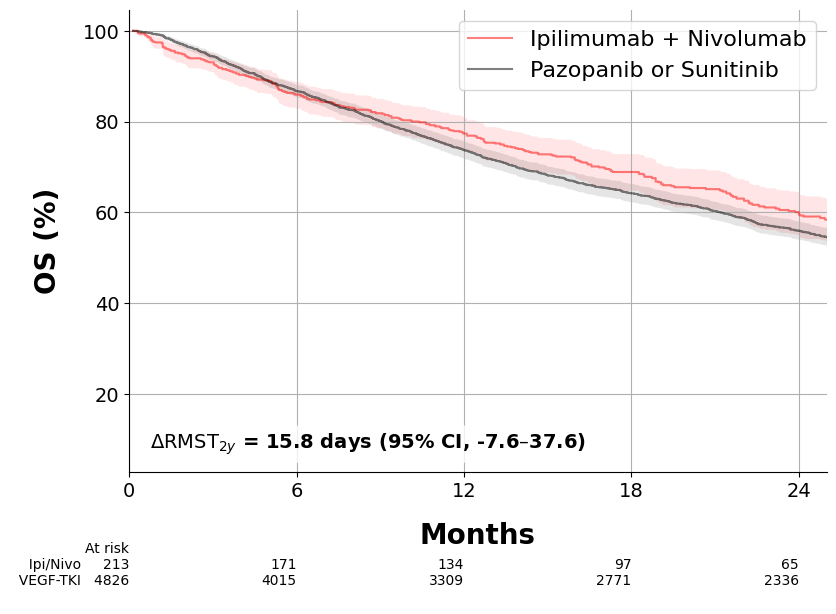

In [30]:
fig = plt.figure(figsize=(9, 6))
ax = plt.gca()

# ipi/nivo estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.treatment_estimate * 100, 
        color='red', 
        alpha=0.5,
        label='Ipilimumab + Nivolumab')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.treatment_lower_ci * 100, 
                km_confidence_intervals_df.treatment_upper_ci * 100, 
                facecolor='red', 
                alpha=0.1)

# tki estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.control_estimate * 100, 
        color='black', 
        alpha=0.5,
        label='Pazopanib or Sunitinib')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.control_lower_ci * 100, 
                km_confidence_intervals_df.control_upper_ci * 100, 
                facecolor='black', 
                alpha=0.1)

tick_months = np.arange(0, 25, 6)   
tick_days = tick_months * 30  
ax.set_xticks(tick_days, labels=[str(m) for m in tick_months])
ax.set_xlim(0, 25 * 30)

ax.set_ylabel('OS (%)', size=20, weight='bold', labelpad=15)
ax.set_xlabel('Months', size=20, weight='bold', labelpad=15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(prop={'size': 16})
ax.grid(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# RMST difference at 3 years
rmst_diff, rmst_lower, rmst_upper = results['difference']['rmst'][730]

rmst_text = (
    r'$\Delta \mathrm{RMST}_{2y}$ = '
    f'{rmst_diff:.1f} days '
    f'(95% CI, {rmst_lower:.1f}–{rmst_upper:.1f})'
)

add_at_risk_counts(
    estimator.treat_km_, 
    estimator.control_km_, 
    rows_to_show=['At risk'], 
    labels=['Ipi/Nivo', 'VEGF-TKI'],
    xticks=tick_days
)

ax.text(
    0.03, 0.05, rmst_text,
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')
)

plt.savefig('../outputs/os_above_crossover.pdf', format='pdf', bbox_inches='tight')